In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle

In [2]:
t_list_lobe1 =np.arange(0.01, 0.26, 0.02) 
t_list_lobe2 =np.arange(0.02, 0.26, 0.02)
t_list_KT=np.arange(0.26, 0.31, 0.01)
t_list_con=np.concatenate([t_list_lobe1, t_list_KT,t_list_lobe2])#拼接数组

t_list= np.sort(t_list_con)#升序排列
 
L_list = np.array([32,64,128])

mup_finite_list=np.zeros((len(t_list),len(L_list)))
muh_finite_list=np.zeros((len(t_list),len(L_list)))
mup_list=np.zeros_like(t_list)
muh_list=np.zeros_like(t_list)

In [3]:
# 以二进制读模式打开文件
with open('energy_results_lobe1.pkl', 'rb') as f:
    results_lobe1 = pickle.load(f)
with open('energy_results_lobe2.pkl', 'rb') as f:
    results_lobe2 = pickle.load(f)
with open('energy_results_KT.pkl', 'rb') as f:
    results_KT = pickle.load(f)

results=results_lobe1+results_KT+results_lobe2

energy_dict = {}
for t, L, excite, E in results:
    energy_dict[(t, L, excite)] = E  
    # 将 results 转换为字典，但元素无序！python不关心键—值对的存储顺序，而只跟踪键和值之间的关联关系。
for i, t in enumerate(t_list):
    for j, L in enumerate(L_list):
        E0 = energy_dict[(t, L, 0)]
        Ep = energy_dict[(t, L, 1)]
        Eh= energy_dict[(t, L, -1)]
        
        mup_finite_list[i, j] = Ep - E0
        muh_finite_list[i, j] = E0-Eh

In [4]:
x = 1.0 / L_list 
for i in range(len(t_list)):
    coeffs_p = np.polyfit(x, mup_finite_list[i,:], deg=1)# 截距=coeffs[1]  斜率=coeffs[0]
    mup_list[i]=coeffs_p[1]
    
    coeffs_h = np.polyfit(x, muh_finite_list[i,:], deg=1)
    muh_list[i]=coeffs_h[1]

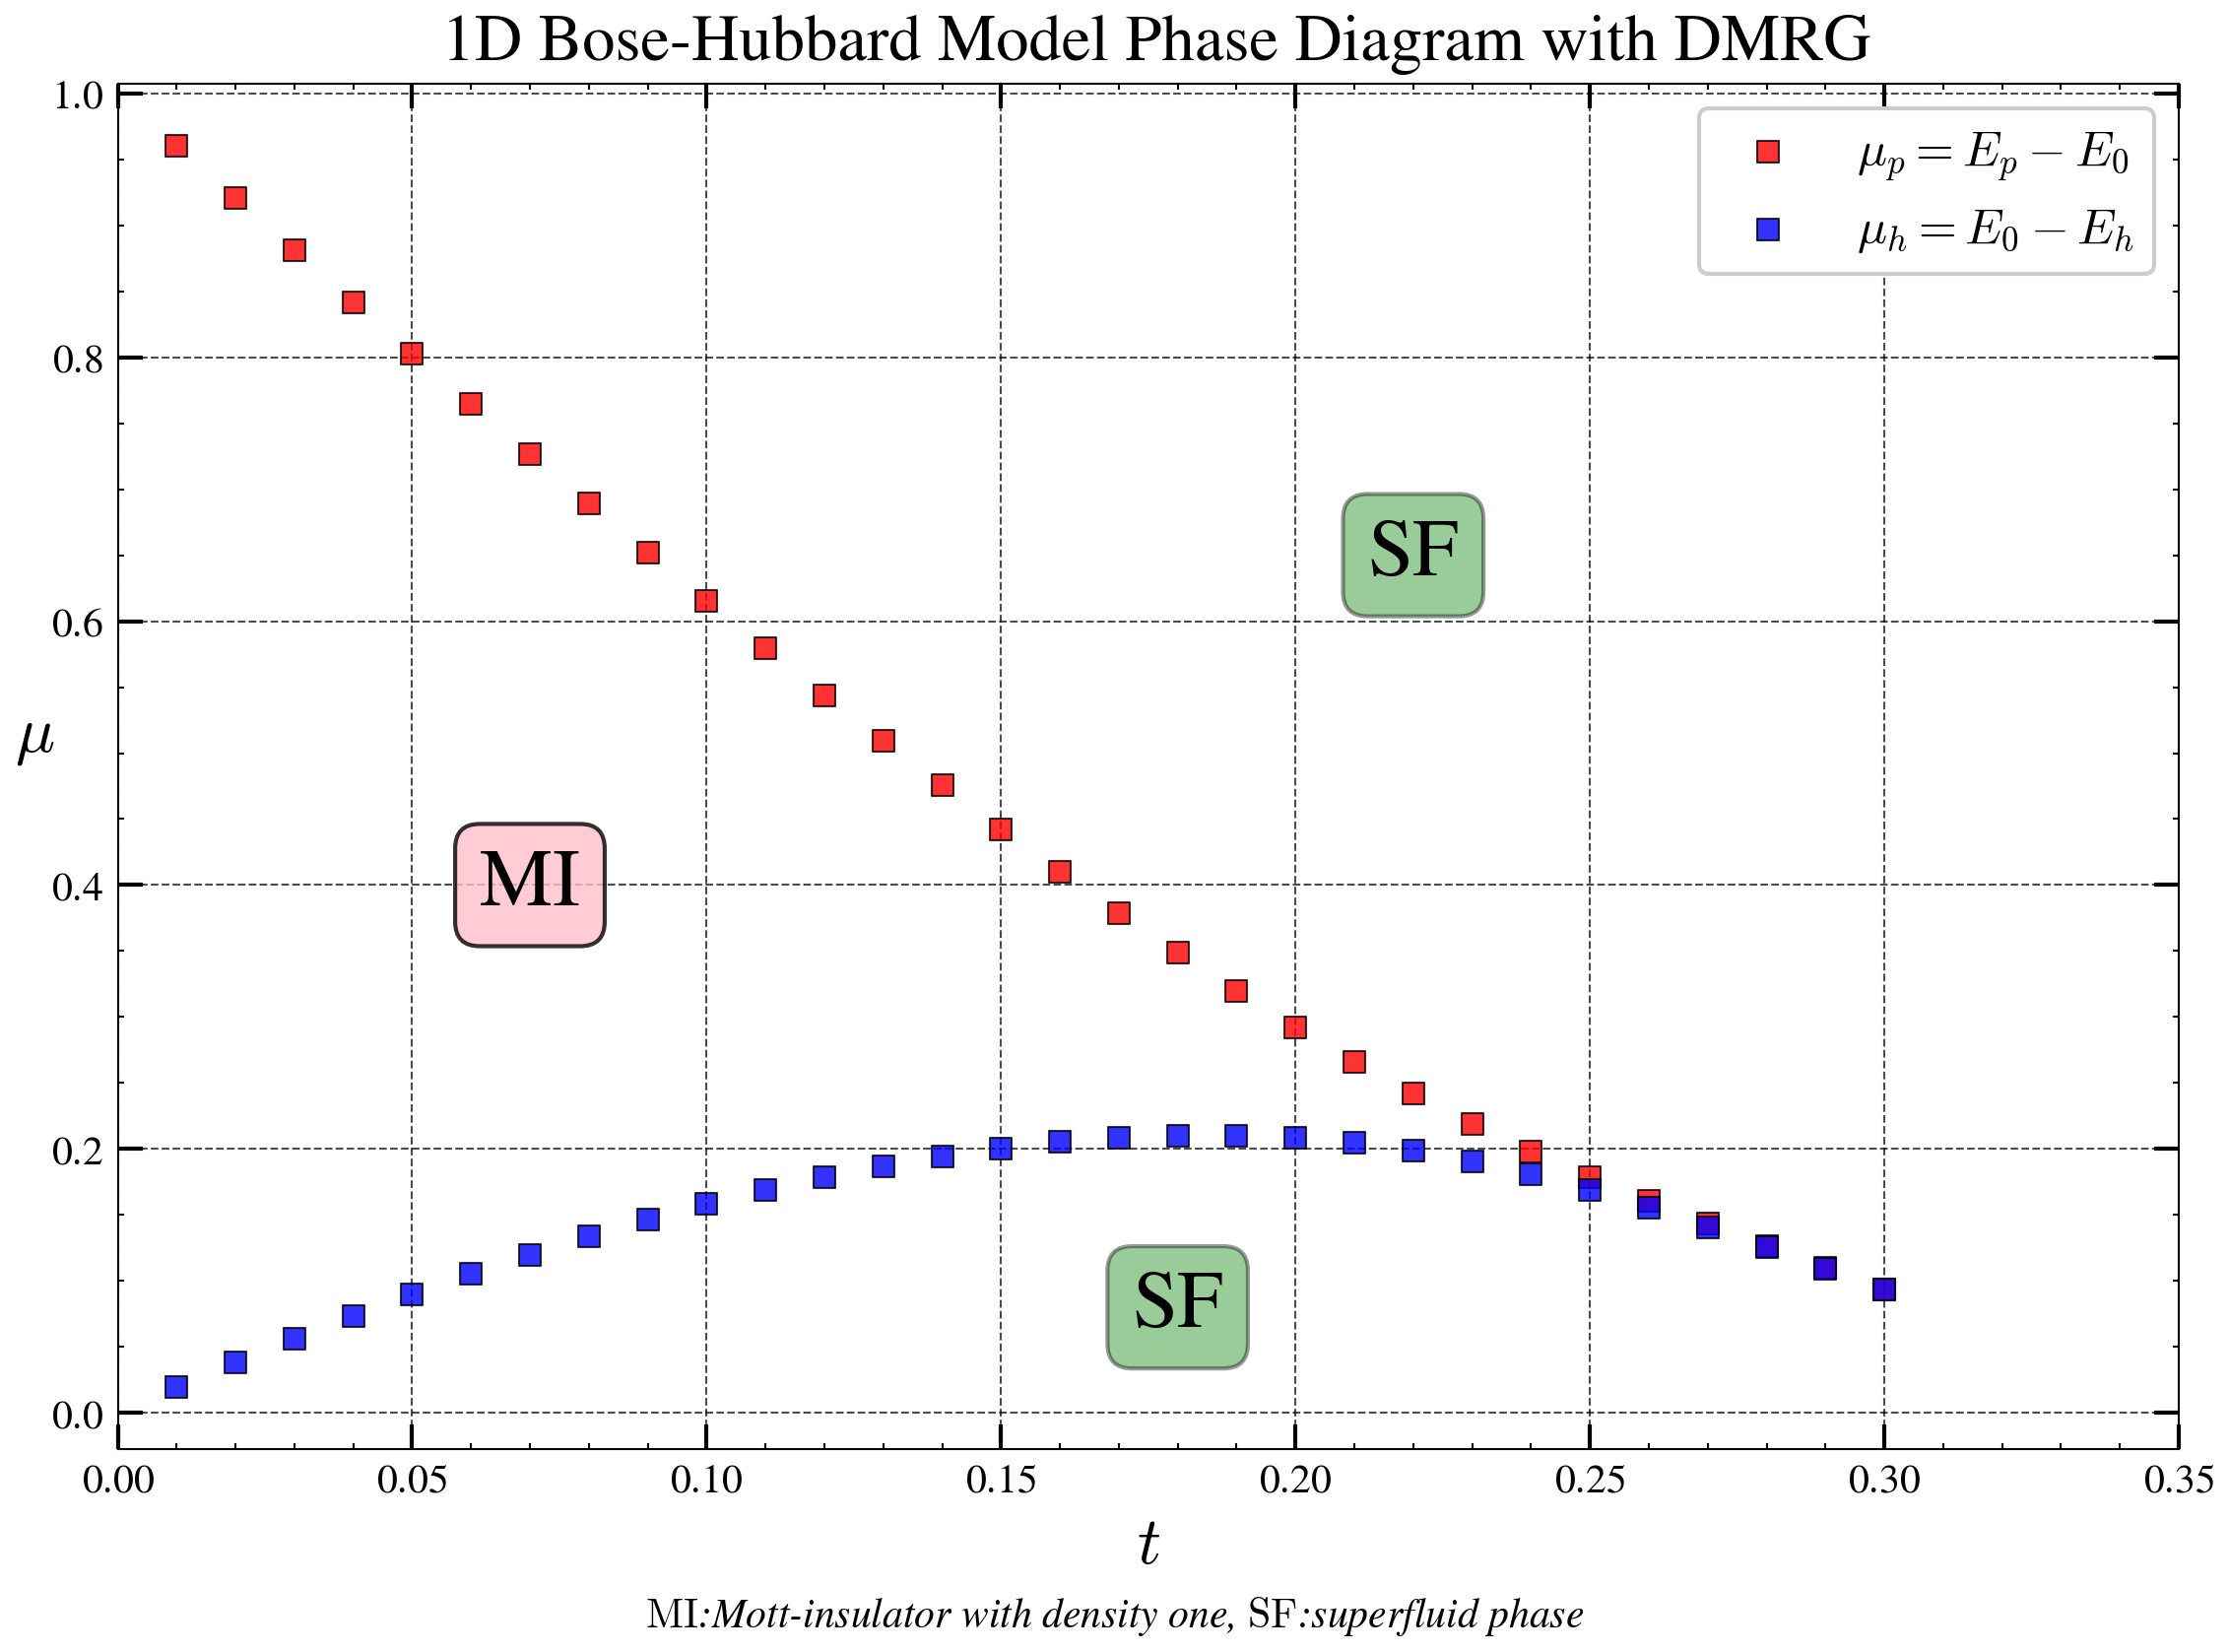

In [5]:
with plt.style.context(['science', 'no-latex', 'grid']):
        fig, ax = plt.subplots(figsize=(9, 6),dpi=300)

        # 绘制散点图（小方块）
        ax.scatter(t_list, mup_list, marker='s', s=26, edgecolors='black', linewidth=0.5,
                label=r'$\mu_p=E_p-E_0$', alpha=0.8,color='red')
        ax.scatter(t_list, muh_list, marker='s', s=26, edgecolors='black', linewidth=0.5,
                label=r'$\mu_h=E_0-E_h$', alpha=0.8,color='blue')

        # 添加标签、标题、网格
        ax.set_xlabel(r'$t$', fontsize=16)
        ax.set_ylabel(r'$\mu$', fontsize=16, rotation=0)
        ax.set_title(' 1D Bose-Hubbard Model Phase Diagram with DMRG', fontsize=16)

        # 设置 x 轴显示范围到 0.35
        ax.set_xlim(0, 0.35)
        # 显示网格（普通网格线）
        ax.grid(True, linestyle='--', alpha=0.7)

        # 让刻度线更明显
        ax.tick_params(axis='both',          # 同时设置 x 和 y 轴
                   which='major',        # 主刻度
                   length=6,             # 刻度线长度（默认约 3.5）
                   width=1,            # 刻度线宽度（默认约 0.8）
                   colors='black',       # 刻度线颜色
                   direction='in',    # 可选：向内向外都画，更醒目
                   top=True, right=True) # 可选：顶部和右侧也显示刻度线
        # 图例
        ax.legend(fontsize=12)
        #fig.tight_layout()

        # 添加区域文字 MI
        ax.text(0.07, 0.4, 'MI', fontsize=20, color='black', weight='normal',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='pink', alpha=0.8))

        # 添加区域文字 SF
        ax.text(0.22, 0.65, 'SF', fontsize=20, color='black', weight='normal',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.4))
        # 添加区域文字 SF
        ax.text(0.18, 0.08, 'SF', fontsize=20, color='black', weight='normal',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.4))

        # 底部注释
        fig.text(0.5, 0.01, 
            r'$\mathrm{MI}$:Mott-insulator with density one, $\mathrm{SF}$:superfluid phase', 
            ha='center', 
            fontsize=10, 
            style='italic')

        # 保存高清图片
        plt.show()
